In [98]:
import jax
import jax.numpy as jnp
import joblib
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binned_statistic, binned_statistic_dd

In [164]:
list_cumtimes = []
list_mean_covs = []
list_std_covs = []

# Time optimization. Uniform distribution

In [165]:
covs_arr, evals_arr, pr_rho0_arr, pr_basis_arr, carry_args = joblib.load(
    "results_single_dot_lately/only_time_opt.job"
)
_, final_iterations, final_dist, data, _, _ = carry_args
final_iteration = final_iterations[0]

data = data[:, : final_iteration - 1]

pr_basis_arr = pr_basis_arr[1:final_iteration]
pr_rho0_arr = pr_rho0_arr[1:final_iteration]

covs_arr = np.transpose(covs_arr[1:final_iteration], [1, 0, 2, 3])
evals_arr = np.transpose(evals_arr[1:final_iteration], [1, 0, 2])

# the index of the cov array is one step behind the data bc of how I saved the data.
# originally, the cov[0] is a zero and no experiment has been done yet.
# Let's have the convention that the experiment[0] should correspond to the first update in
# the covariance, cov[0], (which was cov[1]). The code above fixes this.

In [166]:
cumsum_times = np.cumsum(data.experiment.time, axis=1).squeeze()


cumsum_times_flattened_sorted = np.sort(np.array(cumsum_times).flatten())
indexes_sorted = np.argsort(cumsum_times.flatten())

covariances_flattened_sorted = np.array(covs_arr[:]).reshape(-1, 4, 4)
covariances_flattened_sorted = covariances_flattened_sorted[indexes_sorted, :, :]


no_bins = 1000

cov_mean_list = []
cov_std_list = []

for i in range(4):
    cov_mean_row_list = []
    cov_std_row_list = []

    for j in range(4):
        cov_mean_row_list.append(
            binned_statistic(
                x=cumsum_times_flattened_sorted,
                values=covariances_flattened_sorted[:, i, j],
                statistic="mean",
                bins=no_bins,
            )[0]
        )
        cov_std_row_list.append(
            binned_statistic(
                cumsum_times_flattened_sorted,
                covariances_flattened_sorted[:, i, j],
                statistic="std",
                bins=no_bins,
            )[0]
        )
    cov_mean_list.append(cov_mean_row_list)
    cov_std_list.append(cov_std_row_list)
cov_mean_list = np.array(cov_mean_list).transpose(2, 1, 0)
cov_std_list = np.array(cov_std_list).transpose(2, 1, 0)

cum_times_binned, _, _ = binned_statistic(
    cumsum_times_flattened_sorted,
    cumsum_times_flattened_sorted,
    statistic="mean",
    bins=no_bins,
)

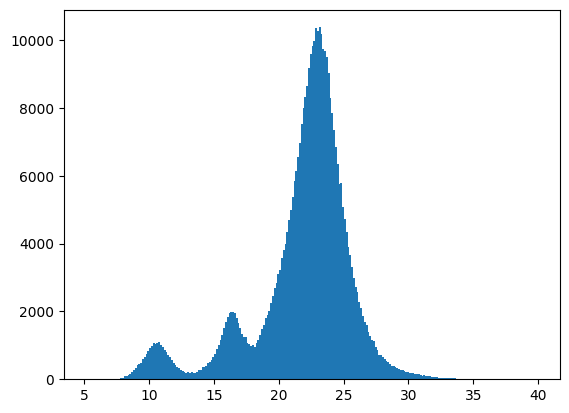

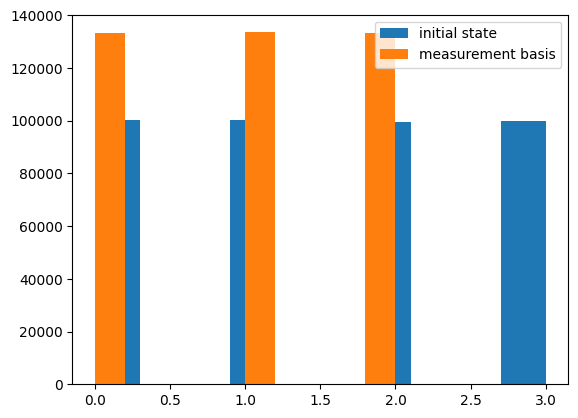

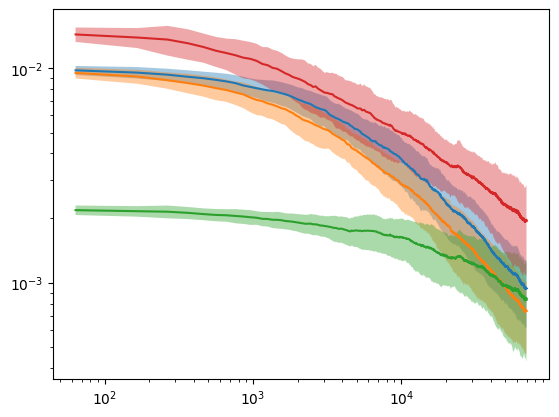

In [167]:
plt.hist(np.array(data.experiment.time).flatten(), bins=250)
plt.show()

plt.hist(np.array(data.experiment.initial_state).flatten(), label="initial state")

plt.hist(
    np.array(data.experiment.measurement_basis).flatten(), label="measurement basis"
)
plt.legend()
plt.show()


end_idx = (np.argwhere(cum_times_binned < 7e4)[-1]).squeeze()
for i in range(4):
    times = cum_times_binned[0:end_idx]
    mean_line = cov_mean_list[0:end_idx, i, i]
    std_line = cov_std_list[0:end_idx, i, i]

    list_cumtimes.append(times)
    list_mean_covs.append(mean_line)
    list_std_covs.append(std_line)


    plt.plot(times, mean_line)
    plt.fill_between(times, mean_line - std_line, mean_line + std_line, alpha=0.4)
    # plt.plot(covariances_arr[:, 0, i, i])
    plt.loglog()

plt.show()

# Time, measurement, and initial state optimization

In [168]:
covs_arr, evals_arr, pr_rho0_arr, pr_basis_arr, carry_args = joblib.load(
    "results_single_dot_lately/summary_all_opt.job"
)
_, final_iterations, final_dist, data, _, _ = carry_args
final_iteration = final_iterations[0]

data = data[:, : final_iteration - 1]

pr_basis_arr = pr_basis_arr[1:final_iteration]
pr_rho0_arr = pr_rho0_arr[1:final_iteration]

covs_arr = np.transpose(covs_arr[1:final_iteration], [1, 0, 2, 3])
evals_arr = np.transpose(evals_arr[1:final_iteration], [1, 0, 2])

# the index of the cov array is one step behind the data bc of how I saved the data.
# originally, the cov[0] is a zero and no experiment has been done yet.
# Let's have the convention that the experiment[0] should correspond to the first update in
# the covariance, cov[0], (which was cov[1]). The code above fixes this.

In [169]:
covs_arr.shape

(100, 3999, 4, 4)

In [170]:
data.experiment.time.shape

(100, 3999, 1)

In [171]:
cumsum_times = np.cumsum(data.experiment.time, axis=1).squeeze()


cumsum_times_flattened_sorted = np.sort(np.array(cumsum_times).flatten())
indexes_sorted = np.argsort(cumsum_times.flatten())

covariances_flattened_sorted = np.array(covs_arr[:]).reshape(-1, 4, 4)
covariances_flattened_sorted = covariances_flattened_sorted[indexes_sorted, :, :]


no_bins = 1000

cov_mean_list = []
cov_std_list = []

for i in range(4):
    cov_mean_row_list = []
    cov_std_row_list = []

    for j in range(4):
        cov_mean_row_list.append(
            binned_statistic(
                x=cumsum_times_flattened_sorted,
                values=covariances_flattened_sorted[:, i, j],
                statistic="mean",
                bins=no_bins,
            )[0]
        )
        cov_std_row_list.append(
            binned_statistic(
                cumsum_times_flattened_sorted,
                covariances_flattened_sorted[:, i, j],
                statistic="std",
                bins=no_bins,
            )[0]
        )
    cov_mean_list.append(cov_mean_row_list)
    cov_std_list.append(cov_std_row_list)
cov_mean_list = np.array(cov_mean_list).transpose(2, 1, 0)
cov_std_list = np.array(cov_std_list).transpose(2, 1, 0)

cum_times_binned, _, _ = binned_statistic(
    cumsum_times_flattened_sorted,
    cumsum_times_flattened_sorted,
    statistic="mean",
    bins=no_bins,
)

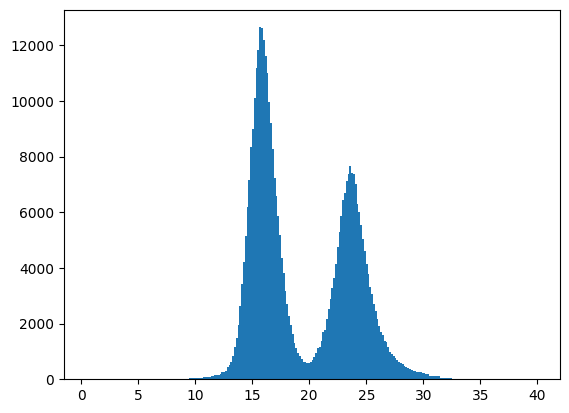

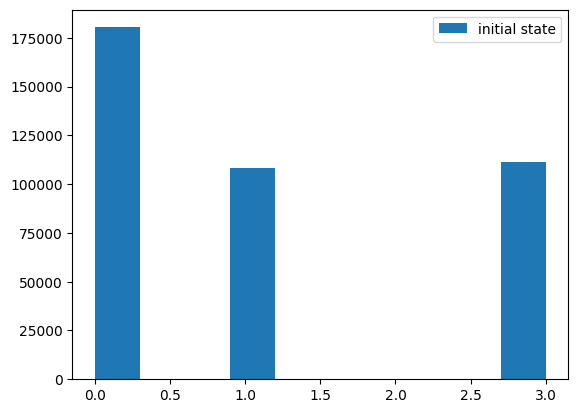

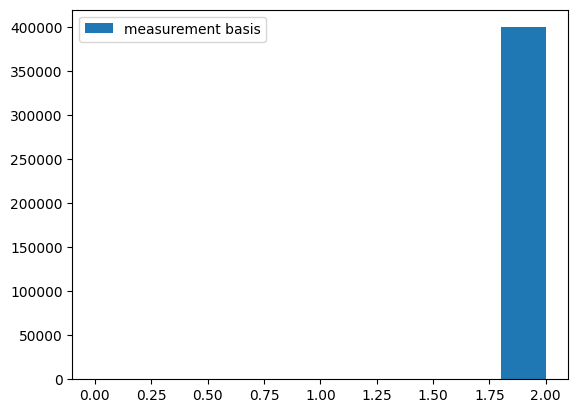

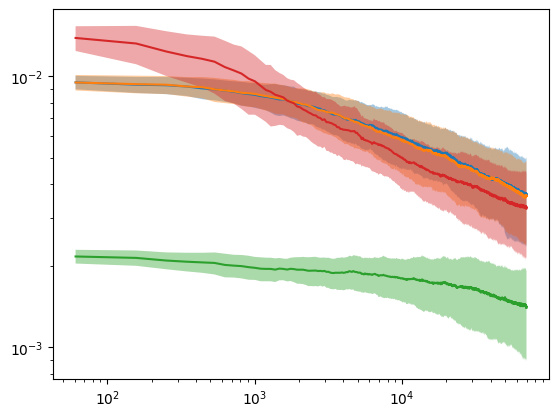

In [172]:
plt.hist(np.array(data.experiment.time).flatten(), bins=250)
plt.show()

plt.hist(np.array(data.experiment.initial_state).flatten(), label="initial state")

plt.legend()
plt.show()
plt.hist(
    np.array(data.experiment.measurement_basis).flatten(), label="measurement basis"
)
plt.legend()
plt.show()


end_idx = (np.argwhere(cum_times_binned < 7e4)[-1]).squeeze()
for i in range(4):
    times = cum_times_binned[0:end_idx]
    mean_line = cov_mean_list[0:end_idx, i, i]
    std_line = cov_std_list[0:end_idx, i, i]
    
    list_cumtimes.append(times)
    list_mean_covs.append(mean_line)
    list_std_covs.append(std_line)
    
    plt.plot(times, mean_line)
    plt.fill_between(times, mean_line - std_line, mean_line + std_line, alpha=0.4)
    # plt.plot(covariances_arr[:, 0, i, i])
    plt.loglog()

plt.show()

In [ ]:
for i in range(4):


    plt.plot(times, mean_line)
    plt.fill_between(times, mean_line - std_line, mean_line + std_line, alpha=0.4)
    # plt.plot(covariances_arr[:, 0, i, i])
    
    plt.loglog()
    